In [1]:
import pandas as pd
import sidetable
import panel as pn
import numpy as np
from sqlalchemy import create_engine
from datetime import date, timedelta
from pandas.tseries.offsets import BDay
import calendar
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set

pn.extension('tabulator')

engine = create_engine("mysql+pymysql://root:@localhost:3306/stock")
const = engine.connect()
engine = create_engine("sqlite:///c:\\ruby\\portmy\\db\\development.sqlite3")
conmy = engine.connect()

data_path = "../data/"
csv_path = "\\Users\\User\\iCloudDrive\\"
box_path = "\\Users\\User\\Dropbox\\"
one_path = "\\Users\\User\\OneDrive\\Documents\\Data\\"
osd_path = "\\Users\\User\\OneDrive\\Documents\\obsidian-git-sync\\Data\\"

today = date.today()
today

datetime.date(2023, 1, 27)

In [2]:
#today = date(2023, 1, 16)

### Set today = last closed business day

In [3]:
num_business_days = BDay(1)
yesterday = today - num_business_days
yesterday = yesterday.date()
today, yesterday

(datetime.date(2023, 1, 27), datetime.date(2023, 1, 26))

### Restart and Run All Cells

In [4]:
sqlUpd = """
UPDATE buy B
SET dividend =
(SELECT DIVIDEND FROM dividend D
WHERE B.name = D.name)"""
rp = const.execute(sqlUpd)
rp.rowcount

27

In [5]:
cols = 'name period shares unit_cost cost_amt base_amt pct'.split()

In [6]:
format_dict = {
    'shares':'{:,}','div_rnk':'{:,}','amt_rnk':'{:,}',  
    'price':'฿{:.2f}','unit_cost':'฿{:.2f}','mkt_price':'฿{:.2f}',
    'cost_amt':'฿{:,.2f}','div_amt':'฿{:,.2f}','mkt_amt':'฿{:,.2f}',
    'cumulative_mkt_amt':'฿{:,.2f}','profit':'฿{:,.2f}','base_amt':'฿{:,.2f}',
    'cumsum':'฿{:,.2f}','dividend':'฿{:.4f}','cumulative_cost_amt':'฿{:,.2f}',    
    'pct':'{:,.2f}%','cost_pct':'{:,.2f}%','mkt_pct':'{:,.2f}%',
    'pft_pct':'{:,.2f}%','percent':'{:,.2f}%','cumulative_percent':'{:,.2f}%',
}

### Discrepancies calculation

In [7]:
sql = '''
SELECT *
FROM buy
WHERE active = 1'''
df = pd.read_sql(sql, const)
df.drop(['volsell', 'volbal'], axis=1, inplace=True)
df.rename(columns={'volbuy': 'shares','price':'unit_cost'}, inplace=True)
df['shares'] = df['shares'].astype('int64')
df['cost_amt'] = df.shares * df.unit_cost
df.shape

(27, 9)

In [8]:
sql = '''
SELECT name, market
FROM stocks
ORDER BY name'''
my_stocks = pd.read_sql(sql, conmy)
my_stocks.shape

(253, 2)

In [9]:
filters = [
   (my_stocks.market.str.contains('SET50')),
   (my_stocks.market.str.contains('SET100')),
   (my_stocks.market.str.contains('mai'))    
]
values = [450000.0,300000.0,150000.0]

In [10]:
my_stocks["base_amt"] = np.select(filters, values, default=150000)
my_stocks.head().style.format(format_dict)

,name,market,base_amt
0,ACE,SET100 / SETTHSI,"฿300,000.00"
1,ADVANC,SET50 / SETHD / SETTHSI,"฿450,000.00"
2,AEONTS,SET,"฿150,000.00"
3,AH,sSET / SETTHSI,"฿150,000.00"
4,AIE,sSET,"฿150,000.00"


In [11]:
df_merge = pd.merge(df, my_stocks, on='name', how='inner')
df_merge.shape

(27, 11)

In [12]:
df_merge['pct'] = round(df_merge.cost_amt/df_merge.base_amt*100,2)
mask = df.period != '2'
df_merge[mask][cols].head().style.format(format_dict)

,name,period,shares,unit_cost,cost_amt,base_amt,pct
0,STA,1,"7,500",฿39.25,"฿294,375.00","฿300,000.00",98.12%
1,SINGER,4,"3,600",฿28.00,"฿100,800.00","฿300,000.00",33.60%
2,KCE,3,"14,000",฿72.75,"฿1,018,500.00","฿300,000.00",339.50%
3,MCS,1,"75,000",฿15.40,"฿1,155,000.00","฿150,000.00",770.00%
5,TMT,1,"36,000",฿10.20,"฿367,200.00","฿150,000.00",244.80%


In [13]:
df_merge[mask].nlargest(5, 'pct')[cols].style.format(format_dict)

,name,period,shares,unit_cost,cost_amt,base_amt,pct
3,MCS,1,"75,000",฿15.40,"฿1,155,000.00","฿150,000.00",770.00%
2,KCE,3,"14,000",฿72.75,"฿1,018,500.00","฿300,000.00",339.50%
22,SYNEX,3,"15,000",฿28.70,"฿430,500.00","฿150,000.00",287.00%
5,TMT,1,"36,000",฿10.20,"฿367,200.00","฿150,000.00",244.80%
16,ORI,3,"45,000",฿11.00,"฿495,000.00","฿300,000.00",165.00%


In [14]:
df_merge[mask].nsmallest(5, 'pct')[cols].style.format(format_dict)

,name,period,shares,unit_cost,cost_amt,base_amt,pct
13,IVL,3,"2,400",฿44.00,"฿105,600.00","฿450,000.00",23.47%
6,JMT,4,"2,400",฿58.50,"฿140,400.00","฿450,000.00",31.20%
20,JMART,4,"3,600",฿39.50,"฿142,200.00","฿450,000.00",31.60%
10,BANPU,4,"12,000",฿12.30,"฿147,600.00","฿450,000.00",32.80%
1,SINGER,4,"3,600",฿28.00,"฿100,800.00","฿300,000.00",33.60%


In [15]:
df_merge.stb.freq(["period"], value="cost_amt").style.format(format_dict)

,period,cost_amt,percent,cumulative_cost_amt,cumulative_percent
0,2,"฿5,731,300.00",51.75%,"฿5,731,300.00",51.75%
1,1,"฿2,319,075.00",20.94%,"฿8,050,375.00",72.69%
2,3,"฿2,250,750.00",20.32%,"฿10,301,125.00",93.01%
3,4,"฿774,000.00",6.99%,"฿11,075,125.00",100.00%


### Rank

In [16]:
sql = '''
SELECT B.name, volbuy, B.price AS unit_cost, 
dividend, P.price AS mkt_price, period
FROM buy B 
JOIN price P
ON B.name = P.name
WHERE P.date = "%s"
AND active = 1
ORDER BY period, name'''
sql = sql % today 
print(sql)


SELECT B.name, volbuy, B.price AS unit_cost, 
dividend, P.price AS mkt_price, period
FROM buy B 
JOIN price P
ON B.name = P.name
WHERE P.date = "2023-01-27"
AND active = 1
ORDER BY period, name


In [17]:
cols = 'name period shares unit_cost cost_amt base_amt pct'.split()
colt = 'name shares unit_cost cost_amt mkt_price mkt_amt amt_rnk mkt_pct div_rnk div_amt'.split()
colu = 'name shares unit_cost cost_amt mkt_price mkt_amt dividend div_amt mkt_pct div_rnk amt_rnk period'.split()

In [18]:
df = pd.read_sql(sql, const)
df.rename(columns={'volbuy': 'shares'}, inplace=True)
df['shares'] = df.shares.astype(int)
df['cost_amt'] = round(df['shares'] * df['unit_cost'], 2)
df['mkt_amt'] = round(df['shares'] * df['mkt_price'], 2)
df['div_amt'] = round(df['shares'] * df['dividend'], 2)
df['cost_pct'] = round(df['div_amt'] / df['cost_amt'] * 100,2)
df['mkt_pct'] = round(df['div_amt'] / df['mkt_amt'] * 100,2)
df['pft_pct'] = round((df['mkt_amt'] - df['cost_amt']) / df['cost_amt'] * 100,2)
df['div_rnk'] = df.mkt_pct.rank(ascending=False)
df['amt_rnk'] = df.mkt_amt.rank(ascending=False)
df[colu].sort_values(['div_rnk'],ascending=[True]).head(15).style.format(format_dict)

,name,shares,unit_cost,cost_amt,mkt_price,mkt_amt,dividend,div_amt,mkt_pct,div_rnk,amt_rnk,period
11,RCL,"24,000",฿39.80,"฿955,200.00",฿31.75,"฿762,000.00",฿7.0000,"฿168,000.00",22.05%,1.0,2.0,2
10,JASIF,"130,000",฿10.00,"฿1,300,000.00",฿8.15,"฿1,059,500.00",฿0.9400,"฿122,200.00",11.53%,2.0,1.0,2
4,TMT,"36,000",฿10.20,"฿367,200.00",฿8.35,"฿300,600.00",฿0.8500,"฿30,600.00",10.18%,3.0,14.0,1
0,ASP,"30,000",฿3.80,"฿114,000.00",฿3.10,"฿93,000.00",฿0.2700,"฿8,100.00",8.71%,4.0,26.0,1
15,WHAIR,"40,000",฿8.95,"฿358,000.00",฿7.80,"฿312,000.00",฿0.6744,"฿26,976.00",8.65%,5.0,12.0,2
13,SENA,"105,000",฿4.48,"฿470,400.00",฿3.92,"฿411,600.00",฿0.3384,"฿35,532.00",8.63%,6.0,8.0,2
9,GVREIT,"40,000",฿8.90,"฿356,000.00",฿9.45,"฿378,000.00",฿0.7786,"฿31,144.00",8.24%,7.0,9.0,2
8,DIF,"40,000",฿14.70,"฿588,000.00",฿13.70,"฿548,000.00",฿1.0410,"฿41,640.00",7.60%,8.0,6.0,2
16,WHART,"30,000",฿11.70,"฿351,000.00",฿11.80,"฿354,000.00",฿0.8941,"฿26,823.00",7.58%,9.0,10.0,2
3,STA,"7,500",฿39.25,"฿294,375.00",฿22.90,"฿171,750.00",฿1.5500,"฿11,625.00",6.77%,10.0,19.0,1


In [19]:
df1 = df[df['period'] == '1'].copy()
df1['div_rnk'] = df1.mkt_pct.rank(ascending=False)
df1['amt_rnk'] = df1.mkt_amt.rank(ascending=False)
df1_out = df1[colt].sort_values('div_rnk')
df1_tab = pn.widgets.Tabulator(df1_out, layout='fit_data', width=950)
df1_tab.style.format(format_dict)

,name,shares,unit_cost,cost_amt,mkt_price,mkt_amt,amt_rnk,mkt_pct,div_rnk,div_amt
4,TMT,"36,000",฿10.20,"฿367,200.00",฿8.35,"฿300,600.00",3.0,10.18%,1.0,"฿30,600.00"
0,ASP,"30,000",฿3.80,"฿114,000.00",฿3.10,"฿93,000.00",5.0,8.71%,2.0,"฿8,100.00"
3,STA,"7,500",฿39.25,"฿294,375.00",฿22.90,"฿171,750.00",4.0,6.77%,3.0,"฿11,625.00"
1,MCS,"75,000",฿15.40,"฿1,155,000.00",฿10.10,"฿757,500.00",1.0,4.95%,4.5,"฿37,500.00"
2,PTTGC,"6,000",฿64.75,"฿388,500.00",฿50.50,"฿303,000.00",2.0,4.95%,4.5,"฿15,000.00"


In [20]:
dividend = df1_out['div_amt'].sum()
market_amt = df1_out['mkt_amt'].sum()
percent = (dividend / market_amt) * 100

In [21]:
dividend, market_amt, percent

(102825.0, 1625850.0, 6.324384168281207)

In [22]:
array = pd.Series([dividend, market_amt])
array = array.map('฿{:,.2f}'.format)
for value in array:
    print(f"The value is: {value}")

The value is: ฿102,825.00
The value is: ฿1,625,850.00


In [23]:
df2 = df[df['period'] == '2'].copy()
df2['div_rnk'] = df2.mkt_pct.rank(ascending=False)
df2['amt_rnk'] = df2.mkt_amt.rank(ascending=False)
df2_out = df2[colt].sort_values('div_rnk')
df2_tab = pn.widgets.Tabulator(df2_out, layout='fit_data', width=950)
df2_tab.style.format(format_dict)

,name,shares,unit_cost,cost_amt,mkt_price,mkt_amt,amt_rnk,mkt_pct,div_rnk,div_amt
11,RCL,"24,000",฿39.80,"฿955,200.00",฿31.75,"฿762,000.00",2.0,22.05%,1.0,"฿168,000.00"
10,JASIF,"130,000",฿10.00,"฿1,300,000.00",฿8.15,"฿1,059,500.00",1.0,11.53%,2.0,"฿122,200.00"
15,WHAIR,"40,000",฿8.95,"฿358,000.00",฿7.80,"฿312,000.00",9.0,8.65%,3.0,"฿26,976.00"
13,SENA,"105,000",฿4.48,"฿470,400.00",฿3.92,"฿411,600.00",5.0,8.63%,4.0,"฿35,532.00"
9,GVREIT,"40,000",฿8.90,"฿356,000.00",฿9.45,"฿378,000.00",6.0,8.24%,5.0,"฿31,144.00"
8,DIF,"40,000",฿14.70,"฿588,000.00",฿13.70,"฿548,000.00",4.0,7.60%,6.0,"฿41,640.00"
16,WHART,"30,000",฿11.70,"฿351,000.00",฿11.80,"฿354,000.00",7.0,7.58%,7.0,"฿26,823.00"
5,BCH,"15,000",฿21.46,"฿321,900.00",฿20.90,"฿313,500.00",8.0,6.70%,8.0,"฿21,000.00"
12,SCCC,"1,200",฿171.00,"฿205,200.00",฿158.50,"฿190,200.00",10.0,5.68%,9.0,"฿10,800.00"
7,DCC,"60,000",฿2.96,"฿177,600.00",฿2.82,"฿169,200.00",11.0,5.67%,10.0,"฿9,600.00"


In [24]:
file_name = 'dividend-050.csv'
data_file = data_path + file_name
output_file = csv_path + file_name
box_file = box_path + file_name
one_file = one_path + file_name
osd_file = osd_path + file_name

df2_out[colt].to_csv(output_file, header=True, index=False)
df2_out[colt].to_csv(data_file, header=True, index=False)
df2_out[colt].to_csv(box_file, header=True, index=False)
df2_out[colt].to_csv(one_file, header=True, index=False)
df2_out[colt].to_csv(osd_file, header=True, index=False)

In [25]:
df2_out['div_amt'].sum()

524613.0

In [26]:
file_name = 'rank-div-market.csv'
data_file = data_path + file_name
output_file = csv_path + file_name
box_file = box_path + file_name
one_file = one_path + file_name

df2.sort_values(['div_rnk'],ascending=[True]).to_csv(output_file, index=False)
df2.sort_values(['div_rnk'],ascending=[True]).to_csv(data_file, index=False)
df.sort_values(['div_rnk'],ascending=[True]).to_csv(box_file, index=False)
df2.sort_values(['div_rnk'],ascending=[True]).to_csv(one_file, index=False)

In [27]:
df.stb.freq(["period"], value="cost_amt").style.format(format_dict)

,period,cost_amt,percent,cumulative_cost_amt,cumulative_percent
0,2,"฿5,731,300.00",51.75%,"฿5,731,300.00",51.75%
1,1,"฿2,319,075.00",20.94%,"฿8,050,375.00",72.69%
2,3,"฿2,250,750.00",20.32%,"฿10,301,125.00",93.01%
3,4,"฿774,000.00",6.99%,"฿11,075,125.00",100.00%


### This statement = Excel 05-CumSum

In [28]:
df.stb.freq(["period"], value="mkt_amt").style.format(format_dict)

,period,mkt_amt,percent,cumulative_mkt_amt,cumulative_percent
0,2,"฿5,164,500.00",55.74%,"฿5,164,500.00",55.74%
1,3,"฿1,757,700.00",18.97%,"฿6,922,200.00",74.71%
2,1,"฿1,625,850.00",17.55%,"฿8,548,050.00",92.25%
3,4,"฿717,900.00",7.75%,"฿9,265,950.00",100.00%


In [29]:
df.stb.freq(["period"], value="div_amt").style.format(format_dict)

,period,div_amt,percent,cumulative_div_amt,cumulative_percent
0,2,"฿524,613.00",71.85%,524613.000000,71.85%
1,1,"฿102,825.00",14.08%,627438.000000,85.93%
2,3,"฿79,240.00",10.85%,706678.000000,96.78%
3,4,"฿23,484.00",3.22%,730162.000000,100.00%


In [30]:
df.stb.freq(["period"]).style.format(format_dict)

,period,count,percent,cumulative_count,cumulative_percent
0,2,12,44.44%,12,44.44%
1,4,5,18.52%,17,62.96%
2,3,5,18.52%,22,81.48%
3,1,5,18.52%,27,100.00%


C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


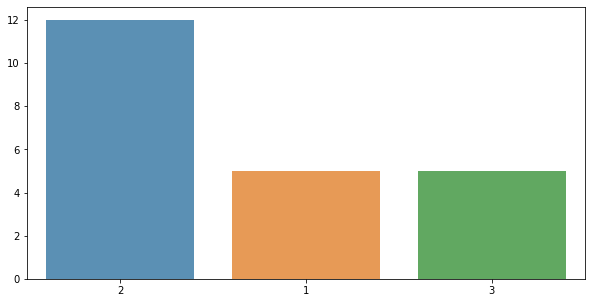

In [31]:
Period_Count =\
df.period.value_counts(sort=True).nlargest(3)
plt.figure(figsize=(10,5))
sns.barplot(Period_Count.index,
Period_Count.values, alpha=0.8)
plt.show()

In [32]:
df9 = df[df['period'] != '2'].copy()
df9['div_rnk'] = df9.mkt_pct.rank(ascending=False)
df9['amt_rnk'] = df9.mkt_amt.rank(ascending=False)
df9_out = df9[colt].sort_values('div_rnk')
df9_out.set_index('name', inplace=True)
df9_tab = pn.widgets.Tabulator(df9_out, layout='fit_data', width=900)
df9_tab

Tabulator(layout='fit_data', value=        shares  ..., width=900)

In [33]:
short_term = (df.period == '4')
df.loc[short_term].head().style.format(format_dict)

,name,shares,unit_cost,dividend,mkt_price,period,cost_amt,mkt_amt,div_amt,cost_pct,mkt_pct,pft_pct,div_rnk,amt_rnk
22,BANPU,"12,000",฿12.30,฿0.7000,฿12.30,4,"฿147,600.00","฿147,600.00","฿8,400.00",5.69%,5.69%,0.00%,13.0,21.0
23,JMART,"3,600",฿39.50,฿1.4600,฿37.25,4,"฿142,200.00","฿134,100.00","฿5,256.00",3.70%,3.92%,-5.70%,23.0,22.0
24,JMT,"2,400",฿58.50,฿0.8200,฿55.50,4,"฿140,400.00","฿133,200.00","฿1,968.00",1.40%,1.48%,-5.13%,27.0,23.0
25,SCC,600,฿405.00,฿8.0000,฿340.00,4,"฿243,000.00","฿204,000.00","฿4,800.00",1.98%,2.35%,-16.05%,26.0,16.0
26,SINGER,"3,600",฿28.00,฿0.8500,฿27.50,4,"฿100,800.00","฿99,000.00","฿3,060.00",3.04%,3.09%,-1.79%,25.0,24.5


In [34]:
data = df.loc[short_term]
names = data['name']
in_p = ", ".join(map(lambda name: "'%s'" % name, names))
in_p

"'BANPU', 'JMART', 'JMT', 'SCC', 'SINGER'"

In [35]:
sql = '''
SELECT name, min_price AS min, price, max_price AS max
FROM stocks
WHERE name IN (%s)'''
sql = sql % in_p
print(sql)

stocks = pd.read_sql(sql, conmy)
stocks.set_index('name',inplace=True)
stocks


SELECT name, min_price AS min, price, max_price AS max
FROM stocks
WHERE name IN ('BANPU', 'JMART', 'JMT', 'SCC', 'SINGER')


,min,price,max
name,,,
BANPU,10.50,12.30,15.00
JMART,35.25,35.50,64.00
JMT,53.75,53.75,88.25
SCC,307.00,334.00,402.00
SINGER,26.25,26.75,59.25


In [36]:
#stocks.drop('SCC',inplace=True)
#stocks

<AxesSubplot:xlabel='name'>

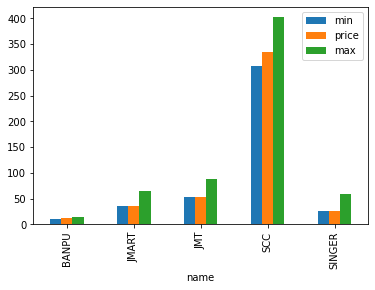

In [37]:
stocks.plot.bar()

In [38]:
#stocks.reset_index('name',inplace=True)
#sns.barplot(x='name', y='price', data=stocks)

### Portfolio cumulative sum by period, name

In [39]:
colw = 'period name shares unit_cost cost_amt mkt_amt cumsum'.split()
df['cumsum'] = df.groupby('period')['mkt_amt'].cumsum()
df[colw].sort_values(by=['period','name'],ascending=[True,True]).style.format(format_dict)

,period,name,shares,unit_cost,cost_amt,mkt_amt,cumsum
0,1,ASP,"30,000",฿3.80,"฿114,000.00","฿93,000.00","฿93,000.00"
1,1,MCS,"75,000",฿15.40,"฿1,155,000.00","฿757,500.00","฿850,500.00"
2,1,PTTGC,"6,000",฿64.75,"฿388,500.00","฿303,000.00","฿1,153,500.00"
3,1,STA,"7,500",฿39.25,"฿294,375.00","฿171,750.00","฿1,325,250.00"
4,1,TMT,"36,000",฿10.20,"฿367,200.00","฿300,600.00","฿1,625,850.00"
5,2,BCH,"15,000",฿21.46,"฿321,900.00","฿313,500.00","฿313,500.00"
6,2,CPNREIT,"30,000",฿19.10,"฿573,000.00","฿585,000.00","฿898,500.00"
7,2,DCC,"60,000",฿2.96,"฿177,600.00","฿169,200.00","฿1,067,700.00"
8,2,DIF,"40,000",฿14.70,"฿588,000.00","฿548,000.00","฿1,615,700.00"
9,2,GVREIT,"40,000",฿8.90,"฿356,000.00","฿378,000.00","฿1,993,700.00"


In [40]:
df.stb.freq(["period"], value="mkt_amt").style.format(format_dict)

,period,mkt_amt,percent,cumulative_mkt_amt,cumulative_percent
0,2,"฿5,164,500.00",55.74%,"฿5,164,500.00",55.74%
1,3,"฿1,757,700.00",18.97%,"฿6,922,200.00",74.71%
2,1,"฿1,625,850.00",17.55%,"฿8,548,050.00",92.25%
3,4,"฿717,900.00",7.75%,"฿9,265,950.00",100.00%
